In [1]:
import numpy as np

from SparseDPC.vectorized.utils import DoubleIntegrator2D, CustomLogger, solve_and_plot_ipopt
from SparseDPC.vectorized.sindy import CompiledFunctionLibrary, SINDyVectorized
from SparseDPC.vectorized.trainer import SparseTrainer, SparsePolicyBuilder
from SparseDPC.vectorized.data import get_policy_data
from SparseDPC.vectorized.plot import *

import neuromancer.psl as psl

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")


## ⚙️ Training System ID with SINDy


### ⚙️ Define Ground Truth System and Problem Parameters



In [2]:
import numpy as np
from neuromancer.psl.signals import step
from neuromancer.psl.base import ODE_NonAutonomous as ODE
from neuromancer.psl.base import cast_backend

class VanDerPolControl(ODE):
    """
    Van der Pol oscillator modified to have relative degree 1 for y = x0.

    Dynamics:
        dx0/dt = x1 + u0
        dx1/dt = mu * (1 - x0^2) * x1 - x0 + u1

    Inputs:
        u0 acts directly on dx0 (gives relative degree 1 w.r.t. y = x0)
        u1 acts on dx1 (original channel)
    Notes:
        - Two input channels are provided in U with shape (nsim, 2): [u0, u1].
        - get_U() returns independent step signals for u0 and u1 by default.
    """

    @property
    def params(self):
        """
        Initializes:
            x0: initial state (2,)
            U: placeholder array with two columns for [u0, u1]
            ts: sampling time
            mu: Van der Pol parameter
        """
        variables = {
            'x0': self.rng.standard_normal(2),
            'U': 0.5 * np.cos(np.arange(0., self.nsim+1) * 0.02).reshape(-1, 1).repeat(2, axis=1)
        }
        constants = {'ts': 0.1}
        parameters = {'mu': 1.0}
        meta = {}
        return variables, constants, parameters, meta

    @cast_backend
    def equations(self, t, x, u):
        """
        Right-hand side of the ODE with two inputs u = [u0, u1].
        """
        dx0 = x[1] + u[0]
        dx1 = self.mu * (1 - x[0]**2) * x[1] - x[0] + u[1]
        return [dx0, dx1]

    @cast_backend
    def get_U(self, nsim, signal=None, **signal_kwargs):
        """
        Default input generator:
            Returns two independent piecewise-constant step signals for [u0, u1].
        """
        if signal is not None:
            return super().get_U(nsim=nsim, signal=signal, **signal_kwargs)
        u0 = step(nsim=nsim, d=1, min=-0.5, max=0.5,
                  randsteps=int(np.ceil(nsim / 200)), rng=self.rng)
        u1 = step(nsim=nsim, d=1, min=-0.5, max=0.5,
                  randsteps=int(np.ceil(nsim / 200)), rng=self.rng)
        return np.concatenate([u0, u1], axis=1)


In [3]:
# ground truth system model
gt_model = VanDerPolControl()
# sampling rate
ts = gt_model.params[1]['ts']
# problem dimensions
nx = gt_model.nx    # number of states
nu = gt_model.nu    # number of control inputs
nref = nx           # number of references
# constraints bounds
umin = -1
umax = 1
xmin = -5.
xmax = 5.



### 🧠 Generate Candidate Sparse Dynamics Models

This cell creates a list of candidate sparse dynamic models for each state dimension using `fx_library`, and prints them for inspection. Each model is configured with the same number of states, inputs, and device.


In [4]:
# build library once
lib = CompiledFunctionLibrary(
    n_features=nx, n_control=nu, is_policy=False,
    include_bias=True, max_degree=4,
    add_sqrt=False, add_xu=True, add_u_prod=True,
    add_fourier=False
)

# create model (multi-output)
sindy = SINDyVectorized(library=lib, n_out=nx, device=device)


### 📊 Get data

Gets training, dev, and test datasets using the ground truth model.


In [5]:
from SparseDPC.data.getdata import get_data

torch.manual_seed(0)


nsim = 2000   # number of simulation steps in the dataset
nsteps = 2  # number of prediction horizon steps in the loss function
bs = 2000     # minibatching batch size
train_loader, dev_loader, test_data = get_data(gt_model, nsim, nsteps, ts, bs)

In [6]:
train_loader.dataset.datadict["X"].max()

tensor(3.5212)

### 🔁 Train SINDy for System ID

Trains a sparse model for each state using one-step loss.
High `epochs` and `prune_every` allow convergence before pruning.
- `threshold`: sparsity cutoff for pruning small weights
- `threshold_mult`: increasing the threshold after prunning, as coefficient of the remaining terms will grow after prunning other unimportant terms


In [7]:
dyn_cfg = {
    # ---------- loss weights ----------
    "onestep_coef"   : 1.0,      # 1-step prediction error
    "ref_coef"       : 2.0,      # full-horizon (n-step) error
    "l1_coef"        : 1e-9,     # L¹ sparsity on SINDy coefficients
    "l1_decay"       : 0.3,

    # ---------- optimiser / schedule ----------
    "lr"             : 1e-3,     # AdamW learning-rate
    "epochs"         : 20000,   # gradient steps per coordinate model

    # ---------- pruning & early-stop ----------
    "threshold"      : 0.11,     # initial coefficient cutoff
    "prune_every"    : 5000,    # epochs between pruning passes
    "threshold_mult" : 1.05,     # threshold ← threshold × multiplier
    "prune_noise"    : 0.05,     # std-dev of regrowth noise (0 ⇒ none)

    # ---------- training conveniences ----------
    "warmup"         : 300,      # epochs before enabling pruning
    "patience"       : 50,       # early-stop patience on dev_loss
}


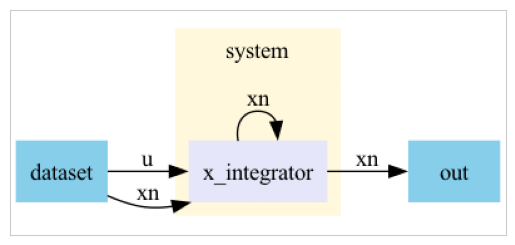

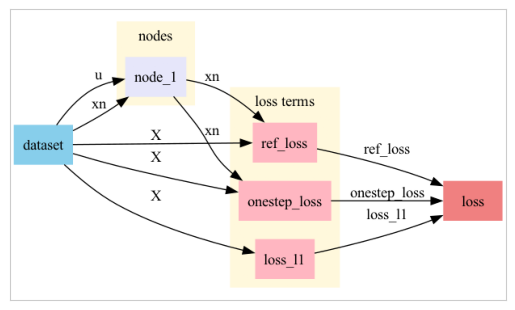

None


In [8]:

from neuromancer.system import Node, System
from neuromancer.constraint import variable
from neuromancer.loss import PenaltyLoss
from neuromancer.problem import Problem
from neuromancer.dynamics import integrators


# One-element integrator for current state
integrator_x = integrators.RK4(sindy, h=ts)
integrator_node_x = Node(integrator_x, ['xn', 'u'], [f'xn'], name="x_integrator")
dynamics_model_x = System([integrator_node_x])
dynamics_model_x.show()

x = variable(f"X")
x_hat = variable(f'xn')[:, :-1, :]

# Define losses
onestep_loss_x = dyn_cfg["onestep_coef"] * ((x_hat[:, 1, :] == x[:, 1, :]) ^ 2)
onestep_loss_x.name = "onestep_loss"

reference_loss_x = dyn_cfg["ref_coef"] * ((x_hat == x) ^ 2)
reference_loss_x.name = "ref_loss"

# L1 sparsity regularization on model weights
l1_x = variable([x], lambda x: sum(torch.norm(p, p=1) for p in sindy.Xi))
loss_l1_x = dyn_cfg["l1_coef"] * (l1_x == 0)
loss_l1_x.name = "loss_l1"

# Assemble problem
objectives_x = [reference_loss_x, onestep_loss_x, loss_l1_x]
loss_x = PenaltyLoss(objectives_x, [])
problem_x = Problem([dynamics_model_x], loss_x)
problem_x.show()

lr = dyn_cfg["lr"]
optimizer_x = torch.optim.AdamW(problem_x.parameters(), lr=lr)

logger = CustomLogger(
    args=None,
    savedir='test',
    verbosity=200,
    stdout=['train_loss','dev_loss']
)




In [9]:

trainer_x = SparseTrainer(
    problem=problem_x,
    sindy=sindy,
    lr=lr,
    train_data=None,
    test_data=None,
    optimizers=optimizer_x,
    epochs=dyn_cfg["epochs"],
    train_metric='train_loss',
    eval_metric='dev_loss',
    logger=logger,
    device= device,
    threshold=dyn_cfg["threshold"],
    prune_every=dyn_cfg["prune_every"],
    warmup=300,
    patience=50,
    threshold_mult=dyn_cfg["threshold_mult"],
    prune_noise=dyn_cfg["prune_noise"],
    l1_decay=dyn_cfg["l1_decay"],
)

# Regenerate training data for updated horizon
trainer_x.train_data, trainer_x.dev_data = train_loader, dev_loader
trainer_x.problem = problem_x

# Train
best_model = trainer_x.train()
trainer_x.model.load_state_dict(best_model)


epoch: 0	train_loss: 6.800e-02	dev_loss: 2.755e+11	eltime:  0.11029
epoch: 200	train_loss: 1.433e-02	dev_loss: 1.613e+01	eltime:  7.57945
epoch: 400	train_loss: 6.279e-03	dev_loss: 1.326e+00	eltime:  15.17772
epoch: 600	train_loss: 3.318e-03	dev_loss: 1.630e-01	eltime:  22.59043
epoch: 800	train_loss: 2.222e-03	dev_loss: 2.639e-02	eltime:  29.94411
epoch: 1000	train_loss: 1.744e-03	dev_loss: 1.988e-02	eltime:  37.86003
epoch: 1200	train_loss: 1.454e-03	dev_loss: 1.994e-02	eltime:  46.06086
epoch: 1400	train_loss: 1.228e-03	dev_loss: 1.739e-02	eltime:  53.72218
epoch: 1600	train_loss: 1.036e-03	dev_loss: 1.622e-02	eltime:  62.11434
epoch: 1800	train_loss: 8.688e-04	dev_loss: 2.085e-02	eltime:  69.92122
epoch: 2000	train_loss: 7.220e-04	dev_loss: 3.388e-02	eltime:  77.73786
epoch: 2200	train_loss: 5.939e-04	dev_loss: 5.505e-02	eltime:  86.47449
epoch: 2400	train_loss: 4.828e-04	dev_loss: 8.124e-02	eltime:  94.26137
epoch: 2600	train_loss: 3.874e-04	dev_loss: 1.078e-01	eltime:  102.04500


<All keys matched successfully>

In [10]:
sindy.pretty_print()

dx0/dt = +1.0000e+00·x1 + +9.9999e-01·u0
dx1/dt = -9.9999e-01·x0 + +9.9994e-01·x1 + +9.9999e-01·u1 + -1.0000e+00·x0^2*x1


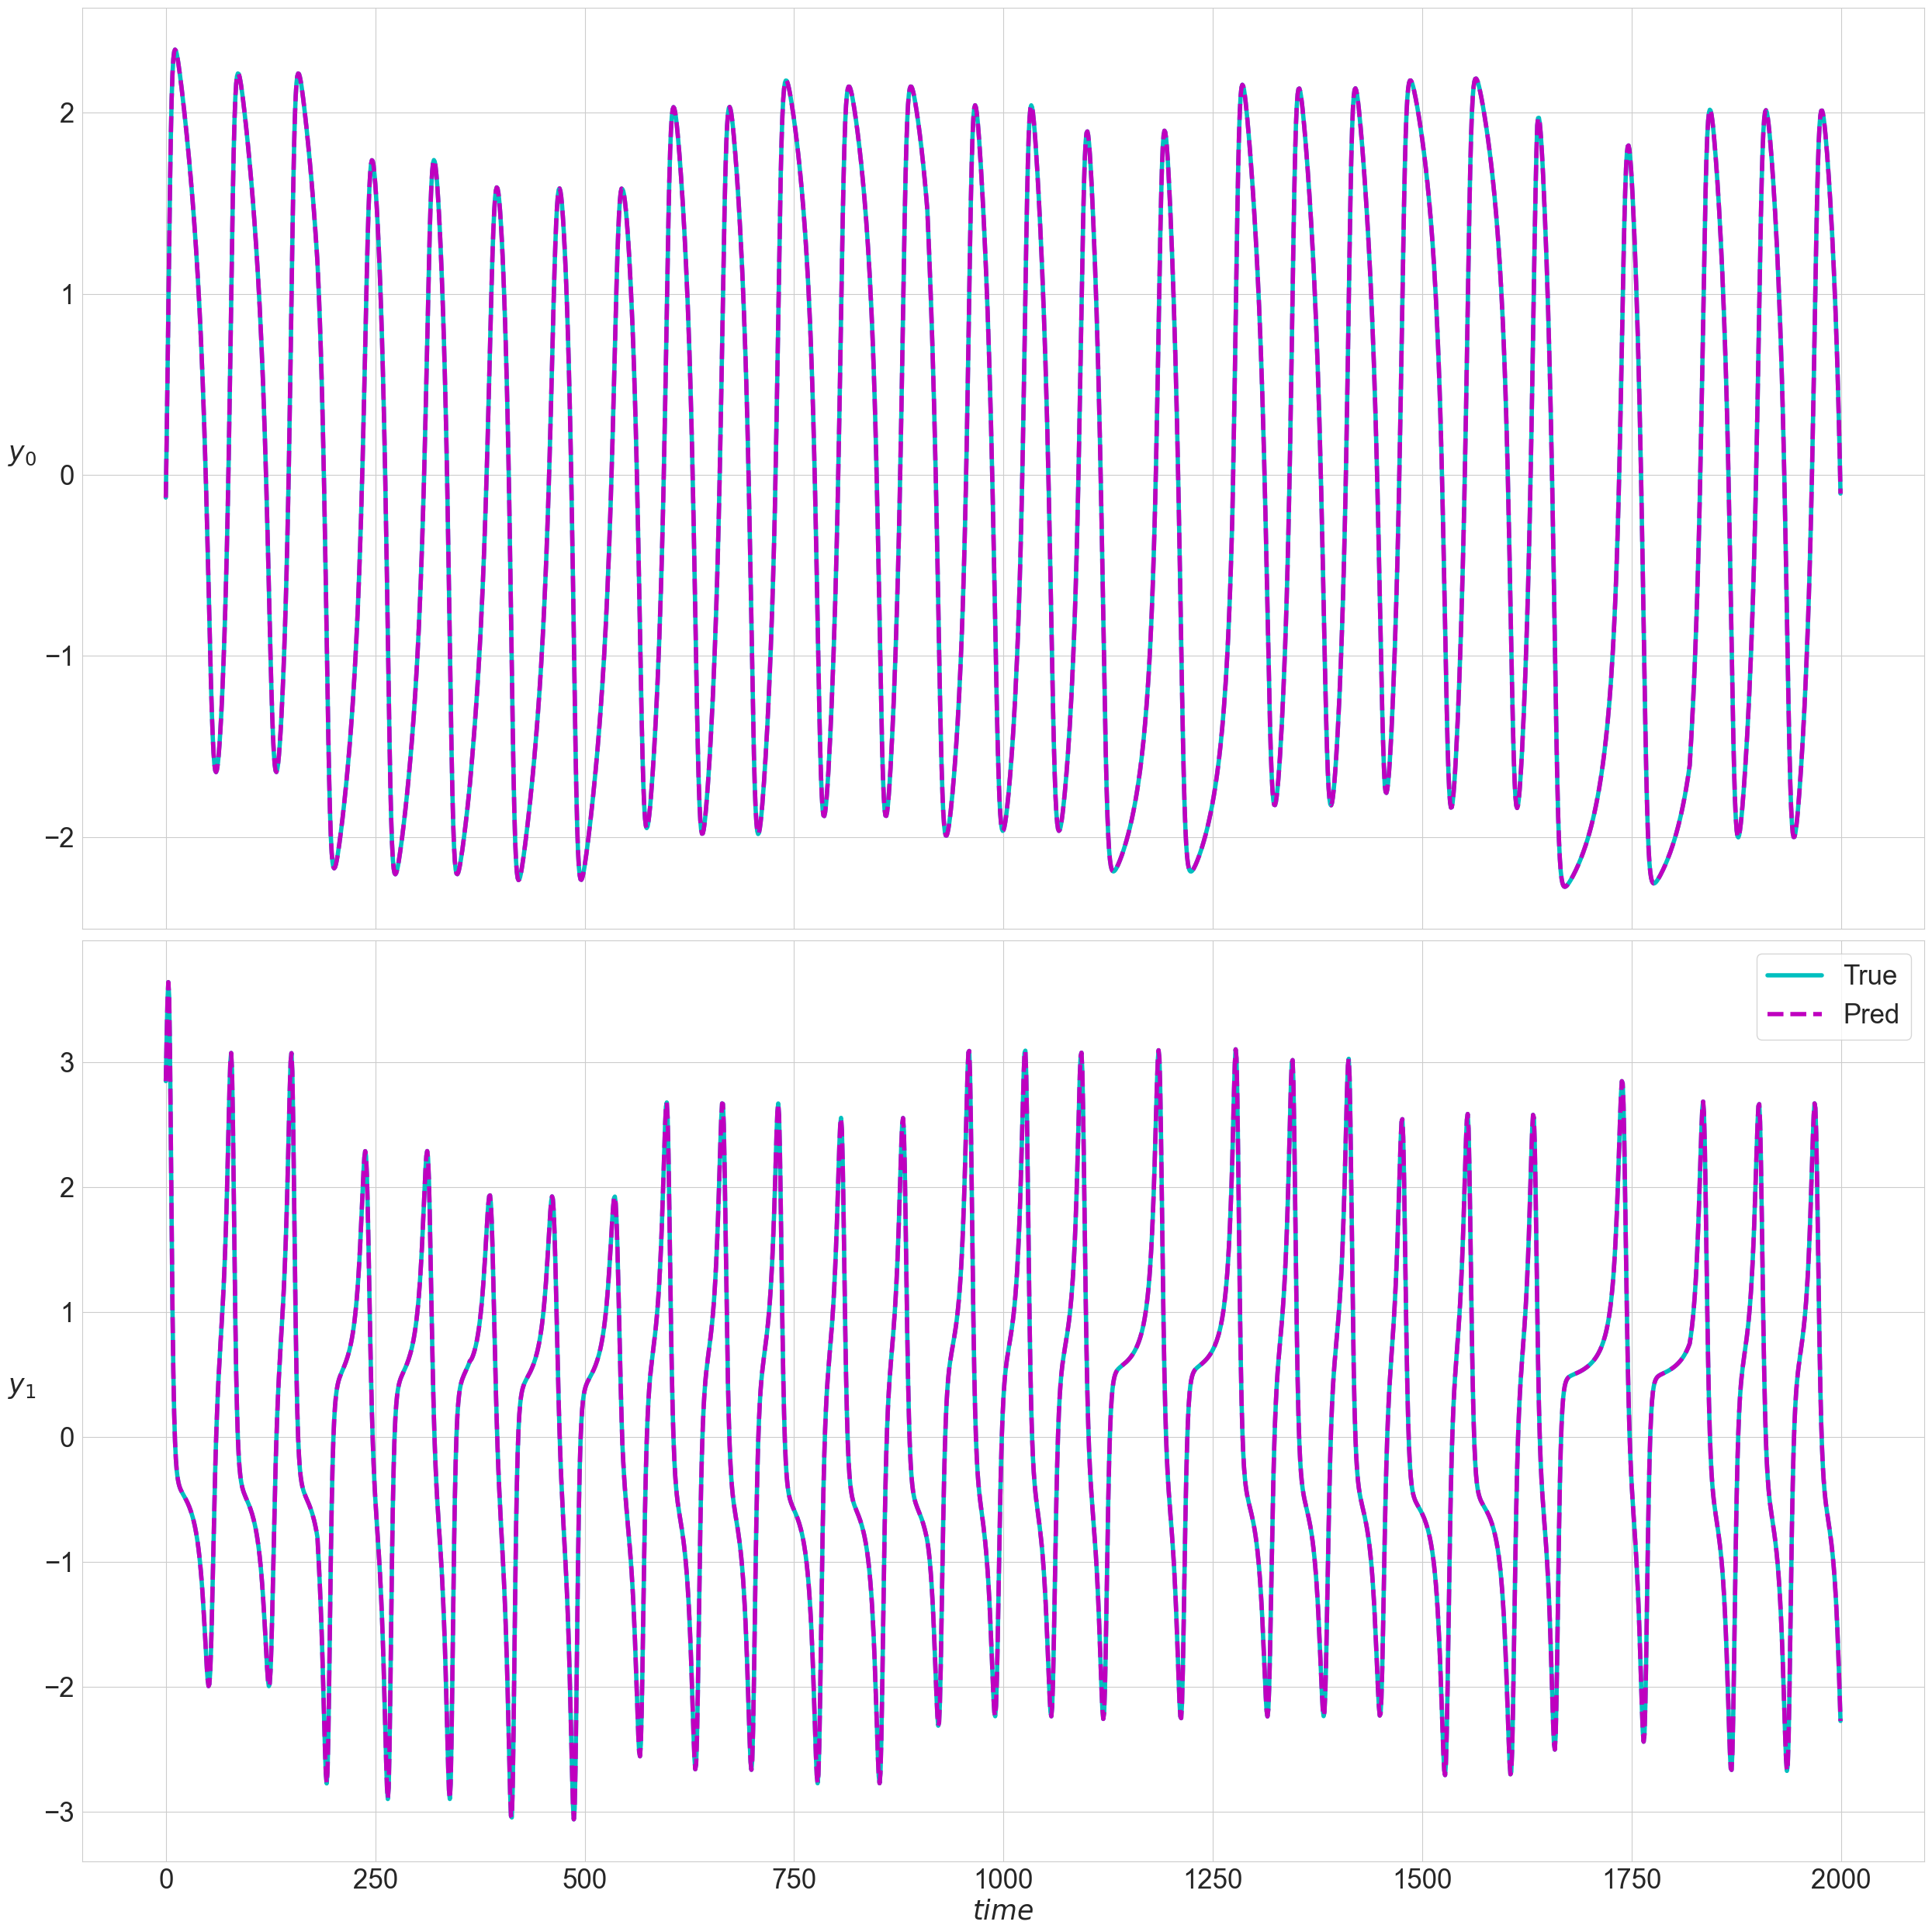

In [11]:
import matplotlib.pyplot as plt

# Create system for evaluation
sindy_system = System([integrator_node_x], nsteps=nsteps)
sindy_system.nsteps = test_data['X'].shape[1]

# Run simulation
test_output = sindy_system(test_data)

# Reshape for plotting
pred_traj = test_output['xn'][:, :-1, :].detach().numpy().reshape(-1, nx).T
true_traj = test_data['X'].detach().numpy().reshape(-1, nx).T

# Plot predicted vs. true trajectories
figsize = 25
fig, ax = plt.subplots(nx, figsize=(figsize, figsize))
labels = [f'$y_{k}$' for k in range(len(true_traj))]

for row, (t1, t2, label) in enumerate(zip(true_traj, pred_traj, labels)):
    axe = ax[row] if nx > 1 else ax
    axe.set_ylabel(label, rotation=0, labelpad=20, fontsize=figsize)
    axe.plot(t1, 'c', linewidth=4.0, label='True')
    axe.plot(t2, 'm--', linewidth=4.0, label='Pred')
    axe.tick_params(labelbottom=False, labelsize=figsize)

axe.tick_params(labelbottom=True, labelsize=figsize)
axe.legend(fontsize=figsize)
axe.set_xlabel('$time$', fontsize=figsize)
plt.tight_layout()


In [12]:
import json, torch
from pathlib import Path

sindy_lib_cfg = dict(
    n_features=lib.n_features,
    n_control=lib.n_control,
    include_bias=lib.include_bias,
    max_degree=lib.max_degree,
    add_sqrt=lib.add_sqrt,
    add_xu=lib.add_xu,
    add_u_prod=lib.add_u_prod,
    add_fourier=lib.add_fourier,
    max_freq=lib.max_freq,
    is_policy=lib.is_policy,
)

sindy_model_cfg = dict(
    n_out=sindy.n_out,
)

ckpt = {
    "lib_cfg": sindy_lib_cfg,
    "model_cfg": sindy_model_cfg,
    "active_idx": sindy.active_idx,          # list[list[int]]
    "state_dict": sindy.state_dict(),        # weights
}


# ---------------- user-supplied objects & constants ------------------------ #
base_dir       = "results/models/dynamics"
# --------------------------------------------------------------------------- #

run_id  = 1
while Path(base_dir, f"run_{run_id}").exists():
    run_id += 1
run_dir = Path(base_dir, f"run_{run_id}");  run_dir.mkdir(parents=True)
(Path(run_dir, "run_config.json")
 .write_text(json.dumps(dyn_cfg, indent=4)))

models_dir = run_dir / "saved_models"; models_dir.mkdir()
torch.save(ckpt, str(models_dir) + "/sindy.pt")   # you can call it .pkl if you want


# Policy

In [13]:
from SparseDPC.data.getdata import get_policy_data

nsteps = 50  # prediction horizon
n_samples = 2000   # number of sampled scenarios
train_loader, dev_loader = get_policy_data(nsteps=nsteps,
                                           n_samples=n_samples,
                                           nx=nx,
                                           xmin=-2.5,
                                           xmax=2.5,
                                           zero_refs=True,
                                           same_ref_for_all_states=True,
                                           device=device,
                                           batch_size=200,
                                           seed=0
                                           )

In [14]:

import importlib
import SparseDPC.vectorized.trainer

importlib.reload(SparseDPC.vectorized.trainer)
from SparseDPC.vectorized.trainer import SparsePolicyBuilder

pol_configs = {
    "reg_coef": 5.0,
    "l1_coef": 0.008,
    "const_coef": 20.0,
    "lr": 0.005,
    "Q_u": 1.0,
    "Q_du": 1.0,
    "Q_dx": 0.0,
    "epochs": 3999,
    "threshold": 0.25,
    "prune_every": 400,
    "threshold_mult": 1.17,
    "prune_noise": 0.02,
    "prune_every_min": 300,
    "prune_every_decay": 200,
    "change_prune_every": True,
    "threshold_max" : 0.5,
    "lr_decay_gamma": 0.95,
    "lr_decay_step": 50,
    "l1_decay": 0.9,
    "warmup":200,
    "patience": 50,
}
policies_seed = 6

policy_lib = CompiledFunctionLibrary(
    n_features=nx, n_control=0, is_policy=True,
    include_bias=False, max_degree=4,
    add_sqrt=False, add_xu=False, add_u_prod=True,
    add_fourier=False, max_freq=2
)

# create model (multi-output)
policy_sparse = SINDyVectorized(library=policy_lib, n_out=nu, policy_name=["u0","u1"], device=device, seed=policies_seed)
policy_sparse.pretty_print()

u0 = +7.2198e-03·x0 + +5.3876e-03·x1 + +4.8683e-02·x0^2 + +1.0803e-02·x0*x1 + -2.6534e-02·x1^2 + -5.0821e-03·x0^3 + +1.7434e-02·x0^2*x1 + +2.4801e-02·x0*x1^2 + +6.0109e-03·x1^3 + -3.3262e-02·x0^4 + -1.6667e-02·x0^3*x1 + -3.5248e-03·x0^2*x1^2 + +1.3324e-02·x0*x1^3 + +2.6925e-02·x1^4
u1 = -2.8530e-02·x0 + +2.8150e-02·x1 + +3.6441e-02·x0^2 + +1.0517e-02·x0*x1 + -1.3503e-02·x1^2 + -2.4642e-02·x0^3 + -3.3580e-02·x0^2*x1 + -2.1668e-02·x0*x1^2 + -1.1418e-02·x1^3 + +3.3375e-02·x0^4 + +1.1732e-02·x0^3*x1 + -1.0767e-02·x0^2*x1^2 + -3.1220e-02·x0*x1^3 + +3.3747e-02·x1^4


None


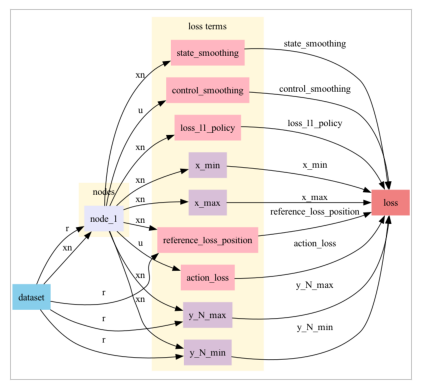

In [15]:
builder_SD_SINDy = SparsePolicyBuilder(
    dynamics_model= sindy,
    policy        = policy_sparse,
    is_sindy      = True,
    gt_model      = None,
    ts            = ts,
    nsteps        = nsteps,
    train_loader  = train_loader,
    dev_loader    = dev_loader,
    bounds        = dict(
                        xmin=xmin,
                        xmax=xmax,
                        umin=umin,
                        umax=umax
                    ),
    config        = pol_configs,
    device        = device,
    logger        = CustomLogger(args=None, savedir='runs', verbosity=10,
                                stdout=['dev_loss', 'train_loss'])
)

In [16]:
builder_SD_SINDy.train()


/opt/anaconda3/envs/neuromancer/lib/python3.10/site-packages/neuromancer/constraint.py:172: UserWarning: Using a target size (torch.Size([])) that is different to the input size (torch.Size([200, 50, 2])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss = F.mse_loss(left, right)


epoch: 0	train_loss: 2.677e+01	dev_loss: 2.628e+01	eltime:  1.44509
epoch: 10	train_loss: 1.113e+01	dev_loss: 1.147e+01	eltime:  9.87112
epoch: 20	train_loss: 4.627e+00	dev_loss: 4.866e+00	eltime:  18.44319
epoch: 30	train_loss: 2.858e+00	dev_loss: 3.067e+00	eltime:  26.92335
epoch: 40	train_loss: 2.276e+00	dev_loss: 2.449e+00	eltime:  35.30676
epoch: 50	train_loss: 2.046e+00	dev_loss: 2.196e+00	eltime:  43.66501
epoch: 60	train_loss: 1.933e+00	dev_loss: 2.075e+00	eltime:  52.23636
epoch: 70	train_loss: 1.871e+00	dev_loss: 2.008e+00	eltime:  60.71120
epoch: 80	train_loss: 1.834e+00	dev_loss: 1.966e+00	eltime:  69.11544
epoch: 90	train_loss: 1.810e+00	dev_loss: 1.939e+00	eltime:  77.44266
epoch: 100	train_loss: 1.792e+00	dev_loss: 1.919e+00	eltime:  85.98601
epoch: 110	train_loss: 1.779e+00	dev_loss: 1.904e+00	eltime:  94.36000
epoch: 120	train_loss: 1.770e+00	dev_loss: 1.894e+00	eltime:  102.73642
epoch: 130	train_loss: 1.762e+00	dev_loss: 1.886e+00	eltime:  111.09331
epoch: 140	train_

In [17]:
import torch
import torch.nn as nn
from neuromancer.dynamics.ode import ODESystem
import copy
class ODEVanDerPolControl(ODESystem):
    """
    Van der Pol oscillator with two inputs to achieve relative degree 1 for y = x1.

    Dynamics:
        x1' = x2 + u0
        x2' = mu * (1 - x1^2) * x2 - x1 + u1

    Inputs:
        u = [u0, u1] with shape (batch, 2)
        u0 acts directly on x1' (gives relative degree 1 for y = x1)
        u1 acts on x2'

    Shapes:
        insize=4 corresponds to [x1, x2, u0, u1]
        outsize=2 corresponds to [x1', x2']
    """
    def __init__(self, insize=4, outsize=2):
        super().__init__(insize=insize, outsize=outsize)
        self.mu = nn.Parameter(torch.tensor([1.0]), requires_grad=True)

    def ode_equations(self, x, u):
        x1 = x[:, [0]]
        x2 = x[:, [1]]
        u0 = u[:, [0]]
        u1 = u[:, [1]]
        dx1 = x2 + u0
        dx2 = self.mu * (1 - x1**2) * x2 - x1 + u1
        return torch.cat([dx1, dx2], dim=-1)


In [18]:
from neuromancer.dynamics import ode
gt_model = VanDerPolControl()
van_der_pol = ODEVanDerPolControl()                   # ODE system equations implemented in PyTorch
# Add parametric noise
van_der_pol.mu = torch.nn.Parameter(torch.tensor(gt_model.mu), requires_grad=False)
# integrate continuous time ODE# integrate continuous time ODE
gt_integrator = integrators.RK4(van_der_pol, h=torch.tensor(ts))   # using 4th order runge kutta integrator
# symbolic system model
gt_integrator_node = Node(gt_integrator, ['xn', 'u'], ['xn'], name='model')

policy_node = Node(
            lambda xn,r : torch.clamp(builder_SD_SINDy.policy(xn, r), umin, umax),
            ['xn', 'r'], ['u'],
            name="policy_combined"
        )
gt_sindy_policy= copy.deepcopy(System([policy_node,
                       gt_integrator_node]))

In [19]:
# from neuromancer.plot import pltCL, pltPhase
# nsteps = 50
# seed = 1
# torch.manual_seed(seed)
# rng = np.random.default_rng(seed)
# xmin = -3.
# xmax = 3.
# # generate reference
# torch_ref = torch.zeros(1, nsteps+1, nx, dtype=torch.float32, device=device)
# data = {'xn': torch.rand(1, 1, nx, dtype=torch.float32) * (xmax-xmin) + xmin,
#         'r': torch_ref}
#
# gt_sindy_policy.nsteps = nsteps
# # perform closed-loop simulation
# trajectories_before_adaptation = gt_sindy_policy(data)
#
# # constraints bounds
# Umin = umin * np.ones([nsteps, nu])
# Umax = umax * np.ones([nsteps, nu])
# Xmin = xmin * np.ones([nsteps+1, nx])
# Xmax = xmax * np.ones([nsteps+1, nx])
# # plot closed loop trajectories
# pltCL(Y=trajectories_before_adaptation['xn'].detach().reshape(nsteps + 1, nx),
#       R=trajectories_before_adaptation['r'].detach().reshape(nsteps + 1, nref),
#       U=trajectories_before_adaptation['u'].detach().reshape(nsteps, nu),
#       Umin=Umin, Umax=Umax, Ymin=Xmin, Ymax=Xmax)

In [20]:
import json, torch
from pathlib import Path

policy_lib_cfg = dict(
    n_features=policy_lib.n_features,
    n_control=policy_lib.n_control,
    include_bias=policy_lib.include_bias,
    max_degree=policy_lib.max_degree,
    add_sqrt=policy_lib.add_sqrt,
    add_xu=policy_lib.add_xu,
    add_u_prod=policy_lib.add_u_prod,
    add_fourier=policy_lib.add_fourier,
    max_freq=policy_lib.max_freq,
    is_policy=policy_lib.is_policy,
)

policy_model_cfg = dict(
    n_out=policy_sparse.n_out,
    policy_name=policy_sparse.policy_name,
)

ckpt = {
    "lib_cfg": policy_lib_cfg,
    "model_cfg": policy_model_cfg,
    "active_idx": policy_sparse.active_idx,          # list[list[int]]
    "state_dict": policy_sparse.state_dict(),        # weights
}

builders       = {"SparseDPC": builder_SD_SINDy}   # tag → builder
base_dir       = "results/models/"
# 1. auto-increment parent run directory
run_id  = 1
while Path(base_dir, f"run_{run_id}").exists():
    run_id += 1
run_dir = Path(base_dir, f"run_{run_id}");  run_dir.mkdir(parents=True)
(Path(run_dir, "run_config.json")
 .write_text(json.dumps(pol_configs, indent=4)))

for tag, bld in builders.items():
    tag_dir    = run_dir / tag;          tag_dir.mkdir()
    models_dir = tag_dir / "saved_models"; models_dir.mkdir()
    torch.save(ckpt, str(models_dir) + "/policy_sparse.pt")   # you can call it .pkl if you want


### NN

None
neural policy(xn, r) -> u
Number of parameters: 1288


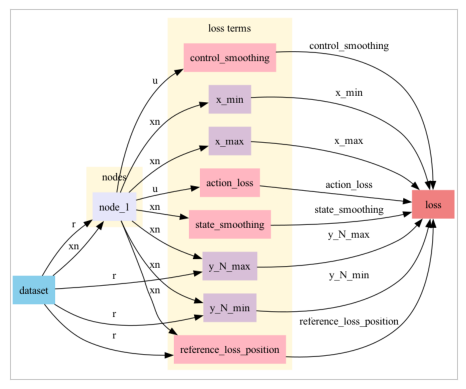

In [21]:
from neuromancer.modules import blocks
from neuromancer.modules.activations import activations
from neuromancer.constraint import variable
from neuromancer.loss import PenaltyLoss
from neuromancer.problem import Problem
from neuromancer.trainer import Trainer
from neuromancer.dynamics import ode, integrators
from neuromancer.loggers import BasicLogger

nsteps=50


nn_config = {
    "layers": [32, 32],
    "reg_coef": 20.0,
    "const_coef": 20.0,
    "lr": 0.005,
    "epochs": 1000,
    "warmup": 1000,
    "patience": 400,
}

# neural net control policy with hard control action bounds
net_sindy = blocks.MLP_bounds(insize=nx + nref, outsize=nu, hsizes=nn_config["layers"],
                    nonlin=activations['gelu'], min=umin, max=umax)
policy_neural_sindy = Node(net_sindy, ['xn', 'r'], ['u'], name='neural policy')


builder_NN_SINDy = SparsePolicyBuilder(
    dynamics_model= sindy,
    policy        = policy_neural_sindy,
    is_sindy      = True,
    gt_model      = None,
    ts            = ts,
    nsteps        = nsteps,
    train_loader  = train_loader,
    dev_loader    = dev_loader,
    bounds        = dict(
                        xmin=xmin,
                        xmax=xmax,
                        umin=umin,
                        umax=umax
                    ),
    config        = pol_configs,
    device        = device,
    logger        = CustomLogger(args=None, savedir='runs', verbosity=10,
                                stdout=['dev_loss', 'train_loss'])
)

In [22]:
builder_NN_SINDy.train()

/opt/anaconda3/envs/neuromancer/lib/python3.10/site-packages/neuromancer/constraint.py:172: UserWarning: Using a target size (torch.Size([])) that is different to the input size (torch.Size([200, 50, 2])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss = F.mse_loss(left, right)


epoch: 0	train_loss: 2.971e+01	dev_loss: 2.932e+01	eltime:  1.37805
epoch: 10	train_loss: 1.732e+00	dev_loss: 1.856e+00	eltime:  10.10336
epoch: 20	train_loss: 1.713e+00	dev_loss: 1.835e+00	eltime:  18.67398
epoch: 30	train_loss: 1.703e+00	dev_loss: 1.824e+00	eltime:  27.07673
epoch: 40	train_loss: 1.697e+00	dev_loss: 1.817e+00	eltime:  35.47015
epoch: 50	train_loss: 1.693e+00	dev_loss: 1.814e+00	eltime:  44.01148
epoch: 60	train_loss: 1.691e+00	dev_loss: 1.811e+00	eltime:  52.33987
epoch: 70	train_loss: 1.689e+00	dev_loss: 1.809e+00	eltime:  60.68510
epoch: 80	train_loss: 1.688e+00	dev_loss: 1.808e+00	eltime:  69.01071
epoch: 90	train_loss: 1.687e+00	dev_loss: 1.807e+00	eltime:  77.54371
epoch: 100	train_loss: 1.686e+00	dev_loss: 1.806e+00	eltime:  85.93252
epoch: 110	train_loss: 1.685e+00	dev_loss: 1.805e+00	eltime:  94.30516
epoch: 120	train_loss: 1.684e+00	dev_loss: 1.804e+00	eltime:  102.75691
epoch: 130	train_loss: 1.683e+00	dev_loss: 1.804e+00	eltime:  111.36542
epoch: 140	train

In [23]:
# policy_node = Node(
#             net_sindy,
#             ['xn', 'r'], ['u'],
#             name="policy_combined"
#         )
# integrator = integrators.RK4(sindy, h=ts)
# integrator_node = Node(integrator, ['xn', 'u'], [f'xn'], name="x_integrator")
#
# gt_sindy_policy= copy.deepcopy(System([policy_node,
#                        integrator_node]))
#
# from neuromancer.plot import pltCL, pltPhase
# nsteps = 100
# seed = 3
# torch.manual_seed(seed)
# rng = np.random.default_rng(seed)
# xmin = -3.
# xmax = 3.
# # generate reference
# torch_ref = torch.zeros(1, nsteps+1, nx, dtype=torch.float32, device=device)
# data = {'xn': torch.rand(1, 1, nx, dtype=torch.float32) * (xmax-xmin) + xmin,
#         'r': torch_ref}
#
# gt_sindy_policy.nsteps = nsteps
# # perform closed-loop simulation
# trajectories_before_adaptation = gt_sindy_policy(data)
#
# # constraints bounds
# Umin = umin * np.ones([nsteps, nu])
# Umax = umax * np.ones([nsteps, nu])
# Xmin = xmin * np.ones([nsteps+1, nx])
# Xmax = xmax * np.ones([nsteps+1, nx])
# # plot closed loop trajectories
# pltCL(Y=trajectories_before_adaptation['xn'].detach().reshape(nsteps + 1, nx),
#       R=trajectories_before_adaptation['r'].detach().reshape(nsteps + 1, nref),
#       U=trajectories_before_adaptation['u'].detach().reshape(nsteps, nu),
#       Umin=Umin, Umax=Umax, Ymin=Xmin, Ymax=Xmax)

In [24]:
import json
import torch
from pathlib import Path

# tag → builder object (must contain .policy)
builders = {
    "NN-DPC": builder_NN_SINDy
}

base_dir = Path("results/models/")

# ---------------------------------------------------
# 1. auto-increment run directory
# ---------------------------------------------------
run_id = 1
while (base_dir / f"run_{run_id}").exists():
    run_id += 1

run_dir = base_dir / f"run_{run_id}"
run_dir.mkdir(parents=True, exist_ok=False)

# ---------------------------------------------------
# 2. Save each builder's models inside its tag folder
# ---------------------------------------------------
for tag, bld in builders.items():

    tag_dir = run_dir / tag
    tag_dir.mkdir(parents=True, exist_ok=False)

    # directory where the model will be saved
    models_dir = tag_dir / "saved_models"
    models_dir.mkdir(parents=True, exist_ok=False)

    # full save path
    save_path = models_dir / "policy_nn.pth"

    # save the policy weights
    torch.save(bld.policy.state_dict(), save_path)

    print(f"Saved {tag} policy → {save_path}")


Saved NN-DPC policy → results/models/run_2/NN-DPC/saved_models/policy_nn.pth


In [25]:
nn_config

{'layers': [32, 32],
 'reg_coef': 20.0,
 'const_coef': 20.0,
 'lr': 0.005,
 'epochs': 1000,
 'warmup': 1000,
 'patience': 400}